# MPAS tutorial: identify → identify → match

This notebook is the complementary sample to `wofs_tutorial.ipynb`, walking through `python_obj`'s object-based thunderstorm verification pipeline for a single-member MPAS forecast (`python_obj/sample_data/mpas_case/mpas_mem1/`, forecast hours f001-f003, 3 real hourly lead times over a small ~750x750 km crop).

Unlike the WoFS case, both the forecast and the matching MRMS observations are **already available on disk** for this sample (bundled directly with the library in `python_obj/sample_data/`, no external test data needed) -- so this notebook skips straight to object identification, with no fetch/interpolate steps needed:

1. **Identify objects in the MPAS forecast** -- no tracking (a single deterministic run has no ensemble spread to track across, and this sample follows a non-tracked workflow on both sides).
2. **Identify objects in MRMS** (the truth series) -- also no tracking.
3. **Match** MPAS objects against MRMS objects via the Total Interest score.

Every step below calls the same `run_one_case(config_path)` function a standalone driver script (`python_obj/drivers/`) would call from the command line -- nothing here is a notebook-only reimplementation. All parameters live in one YAML config file, `python_obj/configs/config_sample_mpas.yaml` (the sample config paired with this notebook; see also `config_sample_wofs.yaml`, the complementary sample that fetches+interpolates from scratch). To adapt this notebook to a different model or case, copy it and point `CONFIG_PATH` (below) at a different config file -- no other code changes needed.

In [1]:
import os
import sys
from collections import Counter

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from python_obj.config import load_config
from python_obj.drivers import identify_track_model, identify_track_mrms, run_matching
from python_obj.obj_core import read_object_file, read_match_file, iter_object_slices

CONFIG_PATH = "../configs/config_sample_mpas.yaml"

cfg = load_config(CONFIG_PATH)
for section_name in ("observations", "model", "matching", "linear_classification"):
    print(f"{section_name}:\n  {getattr(cfg, section_name)}\n")

observations:
  ObservationConfig(file_format='netcdf', var_name='refl_consv', lat_name='lat', lon_name='lon', boundary_threshold=40.0, max_value_threshold=45.0, area_threshold_km2=108.0, interp_mrms_dir='/Users/asdf/Documents/work/2026_analysis/2026_ncar_verif/python_obj/sample_data/mpas_case/interp_mrms/20230501', mask='none', track=False, track_distance_km=0.0, file_grouping='single', object_output_dir='/Users/asdf/Documents/work/2026_analysis/2026_ncar_verif/python_obj/configs/output/obj_mrms_mpas_sample')

model:
  ModelConfig(file_format='netcdf', var_name='refl10cm_max', lat_name='latitude', lon_name='longitude', boundary_threshold=35.0, max_value_threshold=40.0, area_threshold_km2=108.0, input_dir='/Users/asdf/Documents/work/2026_analysis/2026_ncar_verif/python_obj/sample_data/mpas_case/mpas_mem1', init_attr='initializationTime', lead_attr='forecastHour', init_format='%Y%m%d%H', valid_time_attr=None, valid_time_format=None, mask='none', track=False, track_distance_km=0.0, file_

## Step 1 — Object identification on the MPAS forecast (no tracking)

`sample_data/mpas_case/mpas_mem1/` holds one file per forecast hour (`model.member_subdirs: false`, a single deterministic run, not an ensemble). `model.file_pattern` restricts the glob to f001-f003 (3 real hourly lead times; this directory also bundles a separate full-domain f048 file used only by the test suite). Per this sample's workflow, forecast objects are not tracked in time (`model.track: false`).

In [2]:
mpas_object_paths = identify_track_model.run_one_case(CONFIG_PATH)
print(f"Wrote {len(mpas_object_paths)} MPAS object files")

linear_counts = Counter()
total_mpas_objects = 0
for path in mpas_object_paths:
    contents = read_object_file(path)
    total_mpas_objects += len(contents.objects)
    for obj in contents.objects:
        linear_counts[obj.is_linear] += 1

print(f"\nTotal MPAS objects across all {len(mpas_object_paths)} forecast hours: {total_mpas_objects}")
label_names = {0: "cellular", 1: "mixed", 2: "linear"}
print("is_linear distribution (0=cellular, 1=mixed, 2=linear):")
for code in (0, 1, 2):
    print(f"  {label_names[code]}: {linear_counts.get(code, 0)}")

Found 3 manifest entries under '/Users/asdf/Documents/work/2026_analysis/2026_ncar_verif/python_obj/sample_data/mpas_case/mpas_mem1' (member_subdirs=False, stacked_members=False)
Identifying objects: boundary_threshold=35.0, max_value_threshold=40.0, area_threshold_km2=108.0, track=False, file_grouping=single
Wrote 3 MPAS object files

Total MPAS objects across all 3 forecast hours: 7
is_linear distribution (0=cellular, 1=mixed, 2=linear):
  cellular: 2
  mixed: 4
  linear: 1


## Step 2 — Object identification on MRMS (truth, no tracking)

`observations.interp_mrms_dir` points at the bundled `sample_data/mpas_case/interp_mrms/20230501/` -- 3 real hourly files, already interpolated onto the same MPAS grid via the actual `run_batch_interpolation()` library function (see `sample_data/README.md`), no fetch/interpolate steps needed here. Per this sample's workflow, MRMS objects are not tracked either (`observations.track: false`).

In [3]:
mrms_object_paths = identify_track_mrms.run_one_case(CONFIG_PATH)
print(f"Wrote {len(mrms_object_paths)} MRMS object files")

linear_counts = Counter()
total_mrms_objects = 0
for path in mrms_object_paths:
    contents = read_object_file(path)
    total_mrms_objects += len(contents.objects)
    for obj in contents.objects:
        linear_counts[obj.is_linear] += 1

print(f"\nTotal MRMS objects across all {len(mrms_object_paths)} available hours: {total_mrms_objects}")
print("is_linear distribution (0=cellular, 1=mixed, 2=linear):")
for code in (0, 1, 2):
    print(f"  {label_names[code]}: {linear_counts.get(code, 0)}")

Found 3 interpolated MRMS files under '/Users/asdf/Documents/work/2026_analysis/2026_ncar_verif/python_obj/sample_data/mpas_case/interp_mrms/20230501'
Identifying objects: boundary_threshold=40.0, max_value_threshold=45.0, area_threshold_km2=108.0, track=False, file_grouping=single


Wrote 3 MRMS object files

Total MRMS objects across all 3 available hours: 6
is_linear distribution (0=cellular, 1=mixed, 2=linear):
  cellular: 6
  mixed: 0
  linear: 0


## Step 3 — Matching

Each of the 3 MPAS forecast valid times is matched against the nearest-in-time MRMS truth slice (within `matching.max_time_offset_minutes`) via a single global greedy Total Interest (TI) assignment. Every object ends up in exactly one of five categories: `hit`, `miss`, `false_alarm`, `truth_extra`, or `forecast_extra`.

In [4]:
matching_summary = run_matching.run_one_case(CONFIG_PATH)
print(f"Wrote {len(matching_summary.output_paths)} match files")
print(f"Skipped forecast times (no truth within tolerance): {len(matching_summary.skipped_forecast_times)}")

category_counts = Counter()
per_time_counts = {}
for path in matching_summary.output_paths:
    contents = read_match_file(path)
    vt = contents.valid_times[0]
    per_time_counts.setdefault(vt, Counter())
    for rec in contents.records:
        category_counts[rec.category] += 1
        per_time_counts[vt][rec.category] += 1

print(f"\nMatch category totals across all {len(matching_summary.output_paths)} forecast hours:")
for category in ("hit", "miss", "false_alarm", "truth_extra", "forecast_extra"):
    print(f"  {category}: {category_counts.get(category, 0)}")

Found 3 truth files under '/Users/asdf/Documents/work/2026_analysis/2026_ncar_verif/python_obj/configs/output/obj_mrms_mpas_sample'
Found 3 forecast files under '/Users/asdf/Documents/work/2026_analysis/2026_ncar_verif/python_obj/configs/output/obj_mpas_sample'
Matching: max_boundary_disp_km=40.0, max_centroid_disp_km=40.0, ti_threshold=0.2, max_time_offset_minutes=5.0
Wrote 3 match files
Skipped forecast times (no truth within tolerance): 0

Match category totals across all 3 forecast hours:
  hit: 3
  miss: 2
  false_alarm: 4
  truth_extra: 1
  forecast_extra: 0


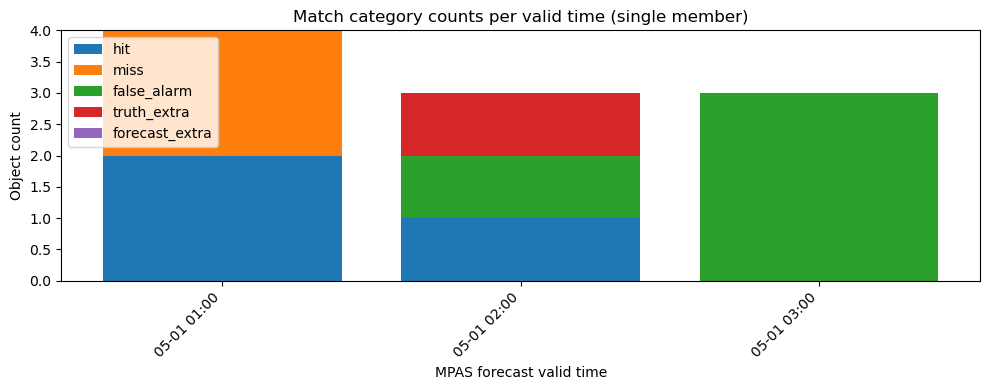

In [5]:
import matplotlib.pyplot as plt

times = sorted(per_time_counts)
categories = ("hit", "miss", "false_alarm", "truth_extra", "forecast_extra")

fig, ax = plt.subplots(figsize=(10, 4))
bottom = [0] * len(times)
for category in categories:
    values = [per_time_counts[t].get(category, 0) for t in times]
    ax.bar([t.strftime("%m-%d %H:%M") for t in times], values, bottom=bottom, label=category)
    bottom = [b + v for b, v in zip(bottom, values)]
ax.set_xlabel("MPAS forecast valid time")
ax.set_ylabel("Object count")
ax.set_title("Match category counts per valid time (single member)")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Closing

This notebook walked through object ID + matching for one real, single-member MPAS forecast, using already-available forecast and interpolated-MRMS data. `wofs_tutorial.ipynb` is the complementary sample notebook -- a real WoFS 18-member ensemble case that fetches MRMS from AWS and interpolates it from scratch, so it demonstrates the full pipeline end to end.

Other example configs in `python_obj/configs/` demonstrate other combinations of the same drivers:

- `config.yaml` -- a full MRMS-vs-MPAS-ensemble chained example (interpolation included).
- `config_smoketest.yaml` -- a minimal small-scale smoke test.
- `config_ensemble.yaml` -- a 2-member MPAS ensemble example.
- `config_sample_wofs.yaml` -- the sample config for `wofs_tutorial.ipynb`.

See `python_obj/drivers/README.md` for each driver's command-line usage and the full config-field reference. To adapt this notebook to a different model or case: copy it, point `CONFIG_PATH` at a new config file matching your data's own conventions, and re-run -- no other code changes are required.